#### Sequence-ability of occupations: GWA-stage monotonicity of the workflow
#### By: Peyman Shahidi
#### Created: 2026-07-25

**Idea.** O*NET's content model orders work activities into a canonical production pipeline, and the DWA
identifiers encode it: `4.A.1` Information Input, `4.A.2` Mental Processes, `4.A.3` Work Output,
`4.A.4` Interacting With Others. An occupation whose workflow marches through these stages (gather, process,
produce, communicate) is sequence-able in a production sense; one that oscillates across stages behaves more
like an unordered task portfolio. This gives an occupation-level sequence-ability measure that uses only the
existing task sequences plus O*NET's own activity hierarchy.

**Construction.** Each task's stage score is the mean stage of its mapped DWAs (most tasks sit in a single
stage; the share spanning several is reported). For each occupation, order the staged tasks by workflow
position and compute:
1. **Stage-position Kendall tau**: rank correlation between position and stage score (tau-b, tie-aware).
2. **Forward-move share**: among adjacent staged tasks whose stages differ, the share of moves down the
   pipeline (later stage). Cycling workflows (repeated input-process-output loops) can score high here while
   scoring lower on tau, so the two statistics bracket the notion.

Occupations enter the index with at least 5 staged tasks and at least 2 distinct stages. **Null:** 1,000
within-occupation reshuffles of the staged subsequence; per-occupation z-scores and aggregate permutation
p-values. Under the null, tau centers at 0 and the forward-move share at one half.

**Robustness columns.** A single-DWA-tasks-only variant (the Prediction-3 universe) and a core-pipeline
variant that drops Interacting-With-Others tasks (stage 4), whose place in the pipeline is most debatable.

**Outputs.** `data/computed_objects/gwaStage_sequenceability/` and `writeup/plots/gwaStage_sequenceability/`.

In [1]:
import os
import numpy as np, pandas as pd
from scipy.stats import kendalltau
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 200); pd.set_option('display.width', 220)

In [2]:
MIN_STAGED = 5      # occupations need >=5 staged tasks (and >=2 distinct stages) to enter the index
N_SHUFFLES = 1000
SEED = 123
STAGE_NAMES = {1: 'Information Input', 2: 'Mental Processes', 3: 'Work Output', 4: 'Interacting With Others'}

main_folder_path = ".."
input_data_path = f"{main_folder_path}/data"
merged_file = f"{input_data_path}/computed_objects/ONET_Eloundou_Anthropic_GPT/ONET_Eloundou_Anthropic_GPT.csv"
mapping_file = f"{input_data_path}/computed_objects/similar_dwa_tasks/dwa_task_mapping.csv"
output_data_path = f"{input_data_path}/computed_objects/gwaStage_sequenceability"
output_plot_path = f"{main_folder_path}/writeup/plots/gwaStage_sequenceability"
for p in [output_data_path, output_plot_path]: os.makedirs(p, exist_ok=True)

## Task-level stage scores and occupation workflows

In [3]:
mapping = pd.read_csv(mapping_file)
mapping['stage'] = mapping['DWA ID'].str.split('.').str[2].astype(int)
per_task = (mapping.drop_duplicates(['Task ID', 'O*NET-SOC Code', 'DWA ID'])
            .groupby(['Task ID', 'O*NET-SOC Code'])
            .agg(stage_score=('stage', 'mean'), n_stages=('stage', 'nunique'), n_dwas=('DWA ID', 'nunique'))
            .reset_index())
core = (mapping[mapping['stage'] < 4].drop_duplicates(['Task ID', 'O*NET-SOC Code', 'DWA ID'])
        .groupby(['Task ID', 'O*NET-SOC Code']).agg(stage_score_core=('stage', 'mean')).reset_index())
per_task = per_task.merge(core, on=['Task ID', 'O*NET-SOC Code'], how='left')

d = pd.read_csv(merged_file)[['O*NET-SOC Code', 'Occupation Title', 'Task ID', 'Task Title', 'Task Position',
                              'Major_Group_Code', 'Major_Group_Title']].copy()
d['Task Position'] = pd.to_numeric(d['Task Position'], errors='coerce')
d = d.dropna(subset=['Task Position']).drop_duplicates(['O*NET-SOC Code', 'Task ID'])
d = d.merge(per_task, on=['Task ID', 'O*NET-SOC Code'], how='left')
d = d.sort_values(['O*NET-SOC Code', 'Task Position']).reset_index(drop=True)
d['staged'] = d['stage_score'].notna()
d['stage_single'] = d['stage_score'].where(d['n_dwas'] == 1)     # single-DWA tasks only (pred-3 universe)

multi_stage_share = (d.loc[d['staged'], 'n_stages'] > 1).mean()
print(f"task-rows: {len(d):,} | staged: {int(d['staged'].sum()):,} ({d['staged'].mean():.1%}) | "
      f"tasks whose DWAs span >1 stage: {multi_stage_share:.1%}")
stage_mix = d.loc[d['staged'] & (d['n_stages'] == 1), 'stage_score'].round().astype(int).value_counts(normalize=True).sort_index()
print("single-stage task composition:", {STAGE_NAMES[k]: f"{v:.1%}" for k, v in stage_mix.items()})

task-rows: 17,920 | staged: 17,496 (97.6%) | tasks whose DWAs span >1 stage: 9.6%
single-stage task composition: {'Information Input': '14.2%', 'Mental Processes': '19.7%', 'Work Output': '35.5%', 'Interacting With Others': '30.6%'}


## Observed sequence-ability by occupation

In [4]:
def seq_stats(s):
    """(kendall tau position vs stage, forward-move share among strict stage changes, non-backward share, n)."""
    s = np.asarray(s, float)
    if len(s) < MIN_STAGED or np.unique(s).size < 2:
        return (np.nan, np.nan, np.nan, len(s))
    tau = float(kendalltau(np.arange(len(s)), s)[0])
    dd = np.diff(s); strict = dd != 0
    fwd = float((dd > 0).sum() / strict.sum()) if strict.any() else np.nan
    nonback = float((dd >= 0).mean())
    return (tau, fwd, nonback, len(s))

occ_rows, seqs = [], {}
for occ, g in d.groupby('O*NET-SOC Code', sort=False):
    s_full = g.loc[g['staged'], 'stage_score'].values
    tau, fwd, nonback, n = seq_stats(s_full)
    tau_1dwa = seq_stats(g['stage_single'].dropna().values)[0]
    tau_core = seq_stats(g['stage_score_core'].dropna().values)[0]
    seqs[occ] = s_full
    occ_rows.append({'O*NET-SOC Code': occ, 'Occupation Title': g['Occupation Title'].iloc[0],
                     'Major_Group_Code': g['Major_Group_Code'].iloc[0],
                     'Major_Group_Title': g['Major_Group_Title'].iloc[0],
                     'n_tasks': len(g), 'n_staged': int(g['staged'].sum()),
                     'tau': tau, 'fwd_share': fwd, 'nonback_share': nonback,
                     'tau_singleDWA': tau_1dwa, 'tau_core3': tau_core})
occ_df = pd.DataFrame(occ_rows)
use = occ_df['tau'].notna()
print(f"occupations: {len(occ_df)} | in index (>= {MIN_STAGED} staged tasks, >=2 stages): {int(use.sum())}")
print(f"tau:        mean {occ_df.loc[use,'tau'].mean():.3f} | median {occ_df.loc[use,'tau'].median():.3f} | "
      f"share > 0: {(occ_df.loc[use,'tau'] > 0).mean():.1%}")
print(f"fwd share:  mean {occ_df.loc[use,'fwd_share'].mean():.3f} | median {occ_df.loc[use,'fwd_share'].median():.3f} | "
      f"share > 0.5: {(occ_df.loc[use,'fwd_share'] > 0.5).mean():.1%}")
print(f"corr(tau, fwd share) = {occ_df.loc[use,['tau','fwd_share']].corr().iloc[0,1]:.3f} | "
      f"corr(tau, single-DWA variant) = {occ_df[['tau','tau_singleDWA']].corr().iloc[0,1]:.3f} | "
      f"corr(tau, core-3-stage variant) = {occ_df[['tau','tau_core3']].corr().iloc[0,1]:.3f}")

occupations: 872 | in index (>= 5 staged tasks, >=2 stages): 864
tau:        mean 0.160 | median 0.160 | share > 0: 76.6%
fwd share:  mean 0.531 | median 0.500 | share > 0.5: 48.4%
corr(tau, fwd share) = 0.411 | corr(tau, single-DWA variant) = 0.870 | corr(tau, core-3-stage variant) = 0.521


## Permutation null: reshuffle each occupation's staged subsequence (1,000 draws)

In [5]:
rng = np.random.default_rng(SEED)
use_occs = occ_df.loc[use, 'O*NET-SOC Code'].tolist()
n_use = len(use_occs)
null_tau = np.empty((N_SHUFFLES, n_use)); null_fwd = np.empty((N_SHUFFLES, n_use))
for b in range(N_SHUFFLES):
    for j, occ in enumerate(use_occs):
        t, f, _, _ = seq_stats(rng.permutation(seqs[occ]))
        null_tau[b, j] = t; null_fwd[b, j] = f
agg_tau_null = np.nanmean(null_tau, axis=1); agg_fwd_null = np.nanmean(null_fwd, axis=1)

obs_tau = occ_df.loc[use, 'tau'].values; obs_fwd = occ_df.loc[use, 'fwd_share'].values
occ_df.loc[use, 'tau_z'] = (obs_tau - np.nanmean(null_tau, axis=0)) / np.nanstd(null_tau, axis=0, ddof=1)
occ_df.loc[use, 'fwd_z'] = (obs_fwd - np.nanmean(null_fwd, axis=0)) / np.nanstd(null_fwd, axis=0, ddof=1)

summary = []
for name, obs_mean, nulldist in [('mean tau across occupations', float(np.nanmean(obs_tau)), agg_tau_null),
                                 ('mean forward-move share', float(np.nanmean(obs_fwd)), agg_fwd_null)]:
    mu, sd = float(np.mean(nulldist)), float(np.std(nulldist, ddof=1))
    z = (obs_mean - mu) / sd
    p = (1 + int((nulldist >= obs_mean).sum())) / (1 + N_SHUFFLES)
    summary.append({'statistic': name, 'observed': obs_mean, 'null_mean': mu, 'null_sd': sd,
                    'z': z, 'p_onesided_greater': p})
    print(f"{name:<32} observed {obs_mean:.3f} | null {mu:.3f} (sd {sd:.4f}) | z = {z:.1f} | p = {p:.4f}")
print(f"\nper-occupation permutation z for tau: share z > 1.645: {(occ_df['tau_z'] > 1.645).mean():.1%} | "
      f"share z > 1.96: {(occ_df['tau_z'] > 1.96).mean():.1%} | share z < -1.96: {(occ_df['tau_z'] < -1.96).mean():.1%}")
pd.DataFrame(summary).to_csv(f"{output_data_path}/summary_stats.csv", index=False)

mean tau across occupations      observed 0.160 | null -0.000 (sd 0.0066) | z = 24.2 | p = 0.0010
mean forward-move share          observed 0.531 | null 0.500 (sd 0.0026) | z = 11.8 | p = 0.0010

per-occupation permutation z for tau: share z > 1.645: 25.6% | share z > 1.96: 18.6% | share z < -1.96: 0.8%


## Face validity: most and least sequence-able occupations (>= 10 staged tasks)

In [6]:
fv = occ_df[use & (occ_df['n_staged'] >= 10)].copy()
print(f"--- TOP 20 (most sequence-able of {len(fv)} occupations) ---")
for _, r in fv.sort_values('tau', ascending=False).head(20).iterrows():
    print(f"  tau {r['tau']:+.2f} | fwd {r['fwd_share']:.2f} | n {r['n_staged']:>2} | {r['Occupation Title'][:70]}")
print("\n--- BOTTOM 20 (least sequence-able) ---")
for _, r in fv.sort_values('tau').head(20).iterrows():
    print(f"  tau {r['tau']:+.2f} | fwd {r['fwd_share']:.2f} | n {r['n_staged']:>2} | {r['Occupation Title'][:70]}")

--- TOP 20 (most sequence-able of 841 occupations) ---
  tau +0.80 | fwd 0.75 | n 11 | Park Naturalists
  tau +0.75 | fwd 0.67 | n 11 | Credit Authorizers, Checkers, and Clerks
  tau +0.74 | fwd 0.60 | n 12 | Political Scientists
  tau +0.69 | fwd 0.67 | n 14 | Craft Artists
  tau +0.67 | fwd 0.38 | n 17 | Occupational Health and Safety Specialists
  tau +0.64 | fwd 0.67 | n 13 | Solar Sales Representatives and Assessors
  tau +0.64 | fwd 0.60 | n 13 | Instructional Coordinators
  tau +0.63 | fwd 0.75 | n 13 | Insulation Workers, Mechanical
  tau +0.62 | fwd 1.00 | n 13 | Machine Feeders and Offbearers
  tau +0.60 | fwd 0.71 | n 14 | Urologists
  tau +0.60 | fwd 0.50 | n 14 | Outdoor Power Equipment and Other Small Engine Mechanics
  tau +0.60 | fwd 0.67 | n 18 | Choreographers
  tau +0.59 | fwd 0.67 | n 14 | Talent Directors
  tau +0.59 | fwd 0.60 | n 14 | Climate Change Policy Analysts
  tau +0.59 | fwd 0.60 | n 21 | Art Therapists
  tau +0.58 | fwd 0.50 | n 15 | Historians
  tau +0.

## Sequence-ability by SOC major group

Major_Group_Code                                          Major_Group_Title  mean_tau  mean_fwd  n_occs
         19-0000             Life, Physical, and Social Science Occupations  0.214029  0.532756      57
         29-0000         Healthcare Practitioners and Technical Occupations  0.207422  0.525856      78
         17-0000                   Architecture and Engineering Occupations  0.203486  0.549923      55
         53-0000             Transportation and Material Moving Occupations  0.194275  0.521128      47
         33-0000                             Protective Service Occupations  0.186347  0.520861      24
         27-0000 Arts, Design, Entertainment, Sports, and Media Occupations  0.182026  0.549112      38
         25-0000            Educational Instruction and Library Occupations  0.181130  0.541603      57
         15-0000                      Computer and Mathematical Occupations  0.163261  0.557681      29
         13-0000              Business and Financial Operations 

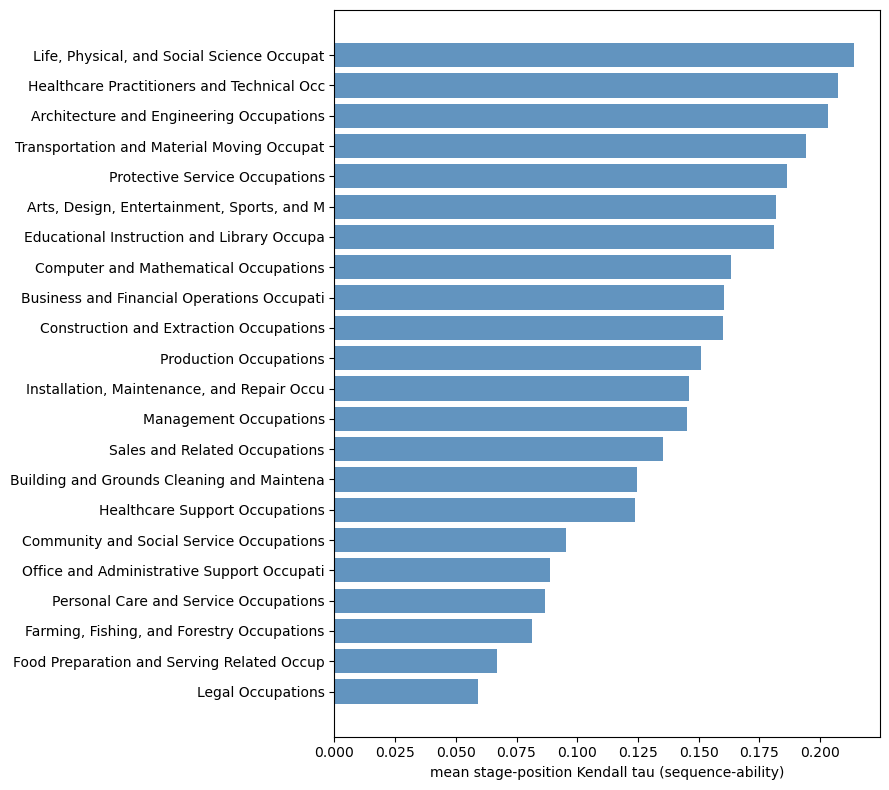

In [7]:
mg = (occ_df[use].groupby(['Major_Group_Code', 'Major_Group_Title'])
      .agg(mean_tau=('tau', 'mean'), mean_fwd=('fwd_share', 'mean'), n_occs=('tau', 'size'))
      .reset_index().sort_values('mean_tau', ascending=False))
print(mg.to_string(index=False))
mg.to_csv(f"{output_data_path}/major_group_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 8))
mgp = mg.sort_values('mean_tau')
ax.barh(mgp['Major_Group_Title'].str.slice(0, 42), mgp['mean_tau'], color='steelblue', alpha=0.85)
ax.axvline(0, color='0.25', lw=1.2, ls='--')
ax.set_xlabel('mean stage-position Kendall tau (sequence-ability)')
fig.tight_layout()
fig.savefig(f"{output_plot_path}/sequenceability_by_major_group.png", dpi=200, bbox_inches='tight')
plt.show()

## Distribution of occupation-level sequence-ability vs the reshuffle null

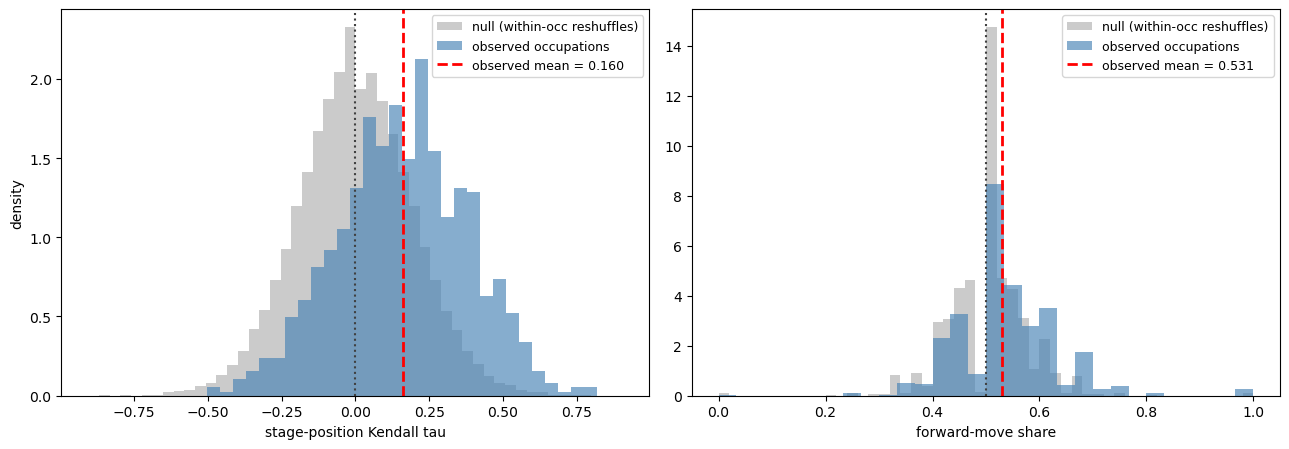

Saved occupation_sequenceability.csv, major_group_summary.csv, summary_stats.csv, null_aggregate_draws.csv
-> ../data/computed_objects/gwaStage_sequenceability


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, obs, nul, lab, ref in [(axes[0], obs_tau, null_tau.ravel(), 'stage-position Kendall tau', 0.0),
                               (axes[1], obs_fwd, null_fwd.ravel(), 'forward-move share', 0.5)]:
    ax.hist(nul[~np.isnan(nul)], bins=50, density=True, color='0.75', alpha=0.8, label='null (within-occ reshuffles)')
    ax.hist(obs[~np.isnan(obs)], bins=30, density=True, color='steelblue', alpha=0.65, label='observed occupations')
    ax.axvline(np.nanmean(obs), color='red', ls='--', lw=2, label=f"observed mean = {np.nanmean(obs):.3f}")
    ax.axvline(ref, color='0.25', ls=':', lw=1.5)
    ax.set_xlabel(lab); ax.legend(fontsize=9)
axes[0].set_ylabel('density')
fig.tight_layout()
fig.savefig(f"{output_plot_path}/sequenceability_distribution_vs_null.png", dpi=200, bbox_inches='tight')
plt.show()

occ_df.sort_values('tau', ascending=False).to_csv(f"{output_data_path}/occupation_sequenceability.csv", index=False)
pd.DataFrame({'agg_mean_tau': agg_tau_null, 'agg_mean_fwd': agg_fwd_null}).to_csv(
    f"{output_data_path}/null_aggregate_draws.csv", index=False)
print("Saved occupation_sequenceability.csv, major_group_summary.csv, summary_stats.csv, null_aggregate_draws.csv")
print("->", output_data_path)

## Reading the results

The occupation-level tau is the sequence-ability index: positive values mean the workflow tends to move down
the O*NET pipeline (input, processing, output, interaction) as it progresses. The per-occupation z-scores say
which occupations are individually more monotone than their own reshuffled workflows; the aggregate permutation
test says whether workflows are pipeline-ordered on average. The forward-move share is the cycling-robust
companion: high values with moderate tau indicate workflows that loop through the pipeline repeatedly.